# Paso 0
Lo primero que se hace es cargar el dataset en Pandas para poder trabajar con los datos. Después, se convierte la columna fecha_venta al formato datetime, porque de esa manera Pandas reconoce las fechas y permite aplicar todas sus funciones temporales. Finalmente, se establece fecha_venta como el índice del DataFrame, lo cual habilita el análisis cronológico y facilita operaciones como resampling, agrupaciones por periodos y comparaciones en el tiempo.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Leemos el archivo y configuramos el índice basado en fechas (siguiendo la práctica recomendada por McKinney)
df_inmuebles = (
    pd.read_csv('files_folder/mercado_inmobiliario.csv')
    .assign(fecha_venta=lambda x: pd.to_datetime(x['fecha_venta']))
    .set_index('fecha_venta')
)

print(f"Archivo cargado: {df_inmuebles.shape[0]} registros disponibles para análisis y gráficos.")

Archivo cargado: 5000 registros disponibles para análisis y gráficos.


# Solución 1: El Pulso del Mercado (Gráfico de Líneas)

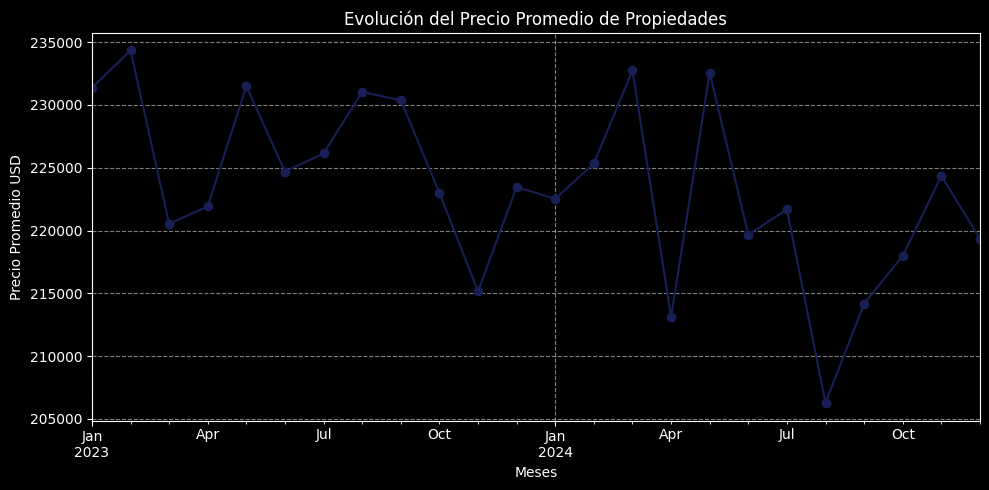

In [2]:
(
    df_inmuebles['precio_usd']
    .resample('ME')
    .mean()
    .plot(
        kind='line',
        figsize=(10, 5),
        color='#171f55',
        linewidth=1.5,
        marker='o',
        title='Evolución del Precio Promedio de Propiedades'
    )
)

plt.xlabel('Meses')
plt.ylabel('Precio Promedio USD')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Solución 2: El Inventario Más Popular (Gráfico de Barras)

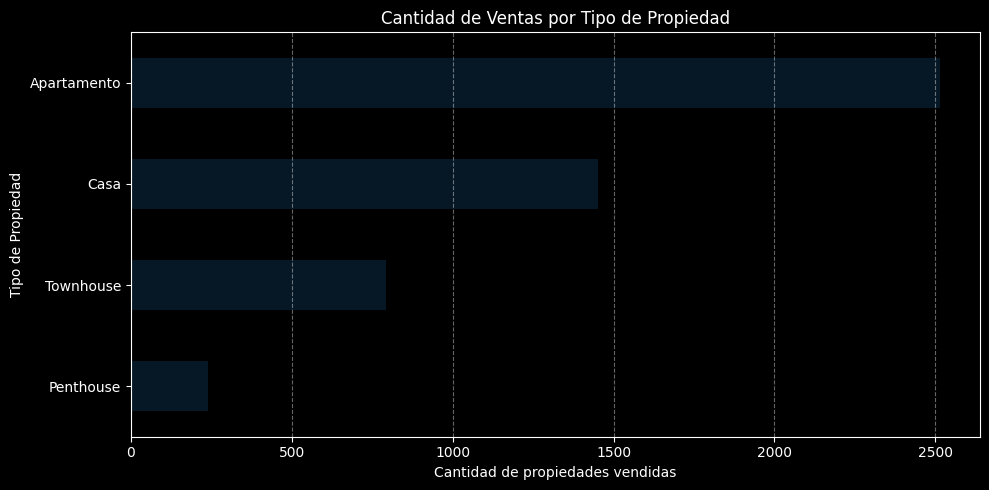

In [3]:
(
    df_inmuebles['tipo_propiedad']
    .value_counts(ascending=True)
    .plot(
        kind='barh',
        figsize=(10, 5),
        color='#061826',
        title='Cantidad de Ventas por Tipo de Propiedad'
    )
)

plt.xlabel('Cantidad de propiedades vendidas')
plt.ylabel('Tipo de Propiedad')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Solución 3: El Estándar de Construcción (Histograma)

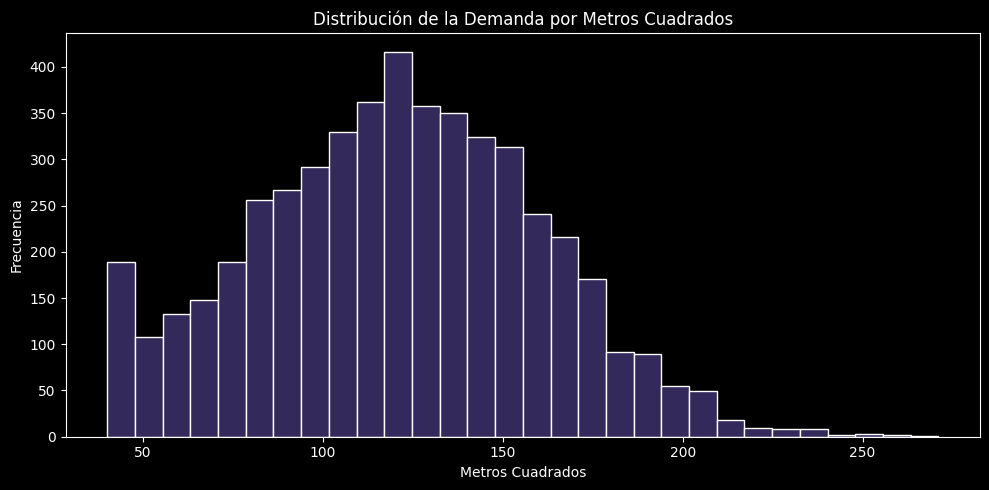

In [4]:
(
    df_inmuebles['metros_cuadrados']
    .plot(
        kind='hist',
        bins=30,
        figsize=(10, 5),
        color='#34295b',
        edgecolor='white',
        title='Distribución de la Demanda por Metros Cuadrados'
    )
)

plt.xlabel('Metros Cuadrados')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Solución 4: Micro-Análisis de Zona (Dispersión + Filtro)

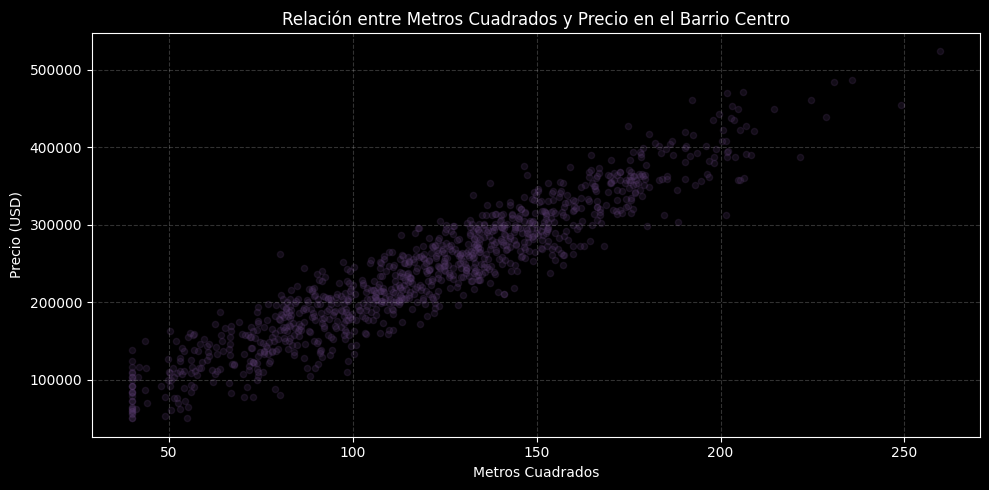

In [5]:
data_centro = df_inmuebles[df_inmuebles["barrio"] == "Centro"]
(
    data_centro
    .plot(
        kind='scatter',
        x='metros_cuadrados',
        y='precio_usd',
        figsize=(10, 5),
        color='#5e4075',
        alpha=0.2,  # Transparencia para ver densidad
        title='Relación entre Metros Cuadrados y Precio en el Barrio Centro'

    )
)

plt.xlabel('Metros Cuadrados')
plt.ylabel('Precio (USD)')
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()